In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the preprocessed reviews
df = pd.read_csv('../data/preprocessed_reviews.csv')

X = df['Cleaned_Text']  # Features (text reviews)
y = df['Sentiment']  # Target (sentiment labels)

print(f"Data shape: {X.shape}")
print(f"Classes: {y.unique()}")

Data shape: (50000,)
Classes: ['Positive' 'Neutral' 'Negative']


In [7]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

print(f"Vectorized X shape: {X.shape}")
print(f"X type: {type(X)}")

Vectorized X shape: (50000, 5000)
X type: <class 'scipy.sparse._csr.csr_matrix'>


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [9]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [10]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, log_pred))

Logistic Regression Accuracy:
0.8525


In [11]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy:
0.8054


In [12]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.8508


In [13]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

    Negative       0.73      0.59      0.65      1405
     Neutral       0.52      0.12      0.20       794
    Positive       0.88      0.97      0.92      7801

    accuracy                           0.85     10000
   macro avg       0.71      0.56      0.59     10000
weighted avg       0.83      0.85      0.83     10000



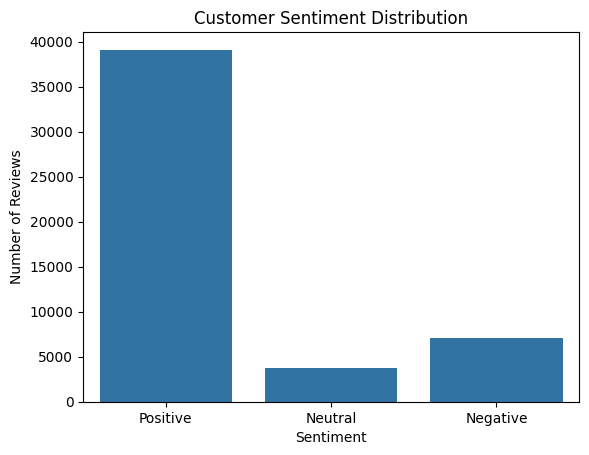

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the preprocessed reviews
df = pd.read_csv("../data/preprocessed_reviews.csv")
sns.countplot(x="Sentiment", data=df)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [3]:
product_sentiment = (
    df.groupby("ProductId")["Sentiment"].value_counts().unstack().fillna(0)
)

product_sentiment.head()

Sentiment,Negative,Neutral,Positive
ProductId,,,
0006641040,0.0,0.0,1.0
2734888454,1.0,0.0,0.0
7310172001,0.0,0.0,20.0
7310172101,0.0,2.0,13.0
B00002N8SM,3.0,0.0,0.0


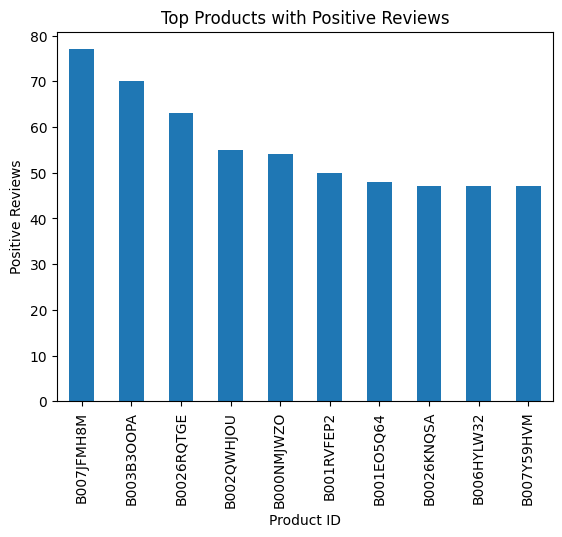

In [5]:
top_positive = product_sentiment.sort_values("Positive", ascending=False).head(10)

top_positive
top_positive["Positive"].plot(kind="bar")

plt.title("Top Products with Positive Reviews")
plt.xlabel("Product ID")
plt.ylabel("Positive Reviews")

plt.show()

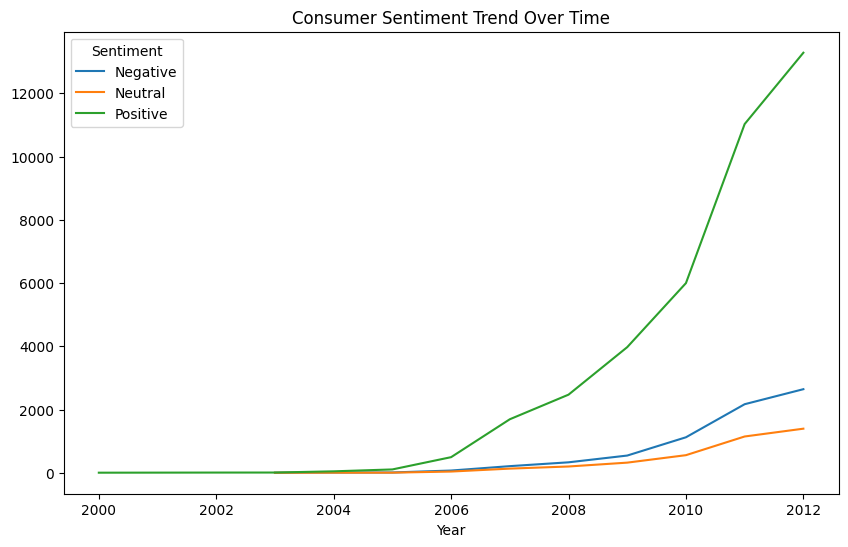

In [7]:
df["Date"] = pd.to_datetime(df["Time"], unit="s")

df["Year"] = df["Date"].dt.year

trend = df.groupby(["Year", "Sentiment"]).size().unstack()

trend.plot(figsize=(10, 6))

plt.title("Consumer Sentiment Trend Over Time")

plt.show()

In [5]:
from collections import Counter

positive_reviews = df[df["Sentiment"] == "Positive"]["Cleaned_Text"]

positive_words = " ".join(positive_reviews)

word_counts = Counter(positive_words.split())

print(word_counts.most_common(20))

[('br', 17861), ('like', 16787), ('good', 14058), ('taste', 13177), ('great', 12986), ('one', 12938), ('love', 12809), ('flavor', 12020), ('coffee', 11539), ('tea', 10853), ('product', 10780), ('food', 10185), ('get', 8003), ('make', 7602), ('would', 6958), ('dog', 6900), ('time', 6653), ('really', 6630), ('also', 6080), ('use', 6035)]


In [ ]:
negative_reviews = df[df["Sentiment"] == "Negative"]["Cleaned_Text"]

negative_words = " ".join(negative_reviews)

word_counts = Counter(negative_words.split())

print(word_counts.most_common(50))

[('like', 3833), ('br', 3623), ('taste', 3394), ('product', 3314), ('one', 2530), ('would', 2342), ('food', 2160), ('flavor', 2070), ('coffee', 2028), ('good', 1873), ('dont', 1482), ('tea', 1479), ('dog', 1474), ('get', 1457), ('even', 1383), ('time', 1368), ('buy', 1328), ('bag', 1318), ('really', 1276), ('box', 1193), ('much', 1184), ('amazon', 1166), ('make', 1084), ('first', 1061), ('im', 1018), ('tried', 1000), ('bought', 954), ('cat', 946), ('better', 889), ('bad', 888), ('try', 887), ('ingredient', 880), ('brand', 862), ('eat', 860), ('little', 856), ('thought', 856), ('love', 854), ('know', 851), ('made', 843), ('got', 842), ('also', 827), ('cup', 817), ('didnt', 815), ('review', 806), ('day', 779), ('water', 778), ('way', 777), ('great', 777), ('two', 774), ('could', 773)]


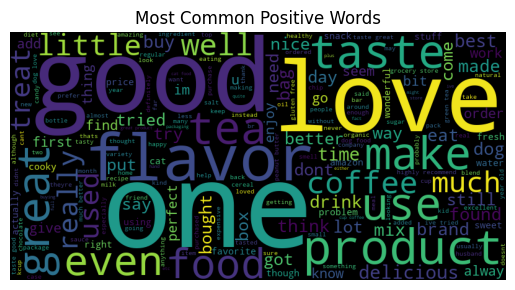

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(positive_words)

plt.imshow(wordcloud)
plt.axis("off")

plt.title("Most Common Positive Words")

plt.show() 

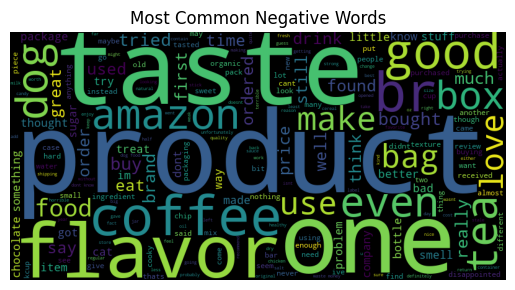

In [9]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(negative_words)

plt.imshow(wordcloud)
plt.axis("off")

plt.title("Most Common Negative Words")

plt.show()